In [1]:
import os
import sys
from pathlib import Path
from typing import final

# setting proper working directory
PROJECT_DIRECTORY = Path(os.path.abspath('')).resolve().parents[0]
sys.path.extend([str(PROJECT_DIRECTORY)])

print(f'Python {sys.version} on {sys.platform}')
print('Project directory: ', PROJECT_DIRECTORY)

Python 3.12.5 (tags/v3.12.5:ff3bc82, Aug  6 2024, 20:45:27) [MSC v.1940 64 bit (AMD64)] on win32
Project directory:  C:\Users\s8347434\Documents\RecBole-GNN\asset


In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.formula.api as sm

In [3]:
# Define custom colors
tu_dd_blue = (0 / 255, 48 / 255, 93 / 255)
bu_green1 = (138 / 255, 203 / 255, 193 / 255)
bu_green2 = (0 / 255, 172 / 255, 169 / 255)
bu_green3 = (0 / 255, 131 / 255, 141 / 255)
ing_blue1 = (132 / 255, 207 / 255, 237 / 255)
ing_blue2 = (0 / 255, 161 / 255, 217 / 255)
ing_blue3 = (0 / 255, 119 / 255, 174 / 255)
ing_blue4 = (0 / 255, 105 / 255, 180 / 255)

dd_concept_mn_green = (148 / 255, 195 / 255, 86 / 255)
dd_concept_bu_green = (138 / 255, 203 / 255, 193 / 255)
dd_concept_ing_blue = (132 / 207, 119 / 255, 237 / 255)
dd_concept_med_red = (205 / 255, 65 / 255, 44 / 255)
dd_concept_leh_orange = (247 / 255, 169 / 255, 65 / 255)

In [4]:
# Function to process columns
def json_dumps_user_columns(df):
    for col in df.columns:
        if col.startswith('best_user_') or col.startswith('worst_user_'):
            # Apply transformation for each row in the selected columns
            df [col] = df[col].apply(json.dumps)
    return df

# Function to process columns
def json_loads_user_columns(df):
    for col in df.columns:
        if col.startswith('best_user_') or col.startswith('worst_user_'):
            # Apply transformation for each row in the selected columns
            df [col] = df[col].apply(json.loads)
    return df

## Read and Transform Benchark Datasets

In [5]:
EVAL_RUN = "RO"
file_path = f"{EVAL_RUN}/EvaluationData.parquet"
if not os.path.isfile(file_path):
    print("File does not exist, run the BuildEvalDataset.ipynb first")
else:
    print(f"File exists! Load file from {file_path}")
    # Load the existing DataFrame
    final_eval_df = pd.read_parquet(file_path, engine="pyarrow")
    #final_eval_df = json_loads_user_columns(final_eval_df)

File exists! Load file from RO/EvaluationData.parquet


In [6]:
# Select only columns ending with @10
columns_to_aggregate = [col for col in final_eval_df.columns if col.endswith('@10')]

# Group by "Model" and aggregate those columns using mean
aggregated_df = final_eval_df.groupby('Model')[columns_to_aggregate].mean().reset_index()

# Display the resulting DataFrame
print(aggregated_df)

         Model  precision@10    hit@10    mrr@10   ndcg@10    map@10  \
0          ALS      0.152966  0.593341  0.329359  0.198749  0.124766   
1  AsymItemKNN      0.124047  0.545569  0.193475  0.137902  0.072963   
2  AsymUserKNN      0.145127  0.583849  0.328943  0.190405  0.117600   
3          BPR      0.138416  0.577249  0.310411  0.178590  0.106081   
4     LightGCN      0.134315  0.569503  0.302034  0.173993  0.102587   
5          Pop      0.039420  0.258159  0.096802  0.048425  0.021056   
6          SGL      0.147338  0.583585  0.319677  0.190309  0.116914   
7     UltraGCN      0.133322  0.551415  0.292251  0.172359  0.104095   
8      XSimGCL      0.150149  0.591894  0.329086  0.194740  0.119951   

   itemcoverage@10  averagepopularity@10  tailpercentage@10  
0         0.075893             57.758945           0.000234  
1         0.130814             46.564064           0.051082  
2         0.108999             74.511185           0.015634  
3         0.080508             

In [7]:
final_eval_df['density_log'] = np.log10(final_eval_df['density'])
final_eval_df['average_clustering_coef_dot_user_log'] = np.log10(final_eval_df['average_clustering_coef_dot_user'])
final_eval_df['average_clustering_coef_dot_item_log'] = np.log10(final_eval_df['average_clustering_coef_dot_item'])
final_eval_df['shape_log'] = np.log10(final_eval_df['shape'])

## Evaluation

In [19]:
# Function to plot metrics by dataset with model averages
def plot_metrics_by_dataset(df, metric, dataset_range=None, models=None, model_names=None, save_fig=False):
    # Ensure the 'metric' column exists in the dataframe
    if metric not in df.columns:
        raise ValueError(f"Metric '{metric}' not found in dataframe columns.")
    
    if dataset_range:
        lower_bound, upper_bound = dataset_range
        df = df[(df['dataset'] >= lower_bound) & (df['dataset'] <= upper_bound)]

    if model_names is None:
        model_names = models
    
    # Check if models list is provided
    if models:
        # Filter DataFrame to include only specified models and set ordering
        df = df[df['Model'].isin(models)]
        df['Model'] = pd.Categorical(df['Model'], categories=model_names, ordered=True)

    # Calculate average metric values for each model
    model_averages = df.groupby('Model', observed=False)[metric].mean()

    colors = [tu_dd_blue, dd_concept_leh_orange, ing_blue1, dd_concept_mn_green, ing_blue3, dd_concept_bu_green, dd_concept_med_red]
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=len(df['Model'].unique()))
    palette = [cmap(i / (len(df['Model'].unique()) - 1)) for i in range(len(df['Model'].unique()))]
    
    plt.figure(figsize=(12, 6))
    lineplot = sns.lineplot(x='dataset', y=metric, hue='Model', data=df, marker='o', markersize=6, palette=palette)

    # Retrieve the colors used for each model from the seaborn plot
    handles, labels = lineplot.get_legend_handles_labels()
    color_map = {label: handle.get_color() for label, handle in zip(labels, handles)}

    # Add horizontal lines for model averages with the corresponding model color
    for model, avg in model_averages.items():
        plt.axhline(avg, linestyle='--', color=color_map[model])

    # Customize plot
    plt.ylabel("NDCG@10", fontsize=25, labelpad=10)
    plt.xlabel('Dataset #', fontsize=25, labelpad=10)

    # Resize and position legend
    plt.legend(
        fontsize=20,                 # Font size for the legend labels (text)
        bbox_to_anchor=(0.5, -0.2),  # Adjusted position
        loc='upper center',          # Align legend at the top-left relative to bbox
        borderaxespad=0.5,         # Padding between legend and axes
        markerscale=1.5,           # Scale marker size in legend
        labelspacing=0.5,          # Space between legend entries
        handlelength=2.0,           # Length of legend line 
        framealpha=0.4,
        ncol=4
    )
    
    if dataset_range and dataset_range[1] >= 176:
        xticks = list(range(10, 176, 20))
        plt.xticks(xticks)  # Adjust step size (e.g., 10) for better label visibility

    ax = plt.gca()  # Get current axes
    for spine in ax.spines.values():
        spine.set_edgecolor('black')  # Set the color of the border
        spine.set_linewidth(1)  # Set the thickness of the border

    # Display grid
    plt.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.3, color='gray')
    
    # Customize ticks
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    
    plt.subplots_adjust(bottom=0.3, top=0.9)
    
    if save_fig:
        plt.savefig(f"../asset/plots/results_{metric}.png", dpi=300, transparent=True)

    # Display the plot
    plt.show()


In [7]:
# Example usage: Plot MR@10 and NDCG@10
model_list = ['ALS', 'BPR', 'LightGCN', 'UltraGCN', 'SGL', 'XSimGCL']
model_name_list = ['ALS', 'BPR', 'LightGCN', 'UltraGCN', 'SGL', 'XSimGCL']
#plot_metrics_by_dataset(final_eval_df, "ndcg@10", dataset_range=[1,176], models=model_list, model_names=model_name_list, save_fig = True)

In [192]:
def plot_metrics_by_dataset_with_boxplot(df, metric, dataset_range=None, models=None, model_names=None, save_fig = False, with_scatter=False):
    # Ensure the 'metric' column exists in the dataframe
    if metric not in df.columns:
        raise ValueError(f"Metric '{metric}' not found in dataframe columns.")
    
    if dataset_range:
        lower_bound, upper_bound = dataset_range
        df = df[(df['dataset'] >= lower_bound) & (df['dataset'] <= upper_bound)]

    if model_names is None:
        model_names = models
    
    # Check if models list is provided
    if models:
        # Filter DataFrame to include only specified models
        df = df[df['Model'].isin(models)]
        # Map the 'Model' column to the new model names using a dictionary
        model_mapping = dict(zip(models, model_names))
        df['Model'] = df['Model'].map(model_mapping)
        # Set categorical ordering for models
        df['Model'] = pd.Categorical(df['Model'], categories=model_names, ordered=True)

        
    print(df['Model'].unique())

    colors = [tu_dd_blue, dd_concept_leh_orange, ing_blue1, dd_concept_mn_green, ing_blue3, dd_concept_bu_green, dd_concept_med_red, ing_blue2]
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=len(df['Model'].unique()))
    palette = [cmap(i / (len(df['Model'].unique()) - 1)) for i in range(len(df['Model'].unique()))]
    
    # Create the plot using seaborn boxplot
    plt.figure(figsize=(12, 6))
    boxplot = sns.boxplot(
        x='Model', y=metric, data=df, showmeans=True, meanline=True, 
        meanprops={"linestyle": "--", "color": "black"}, 
        hue='Model', dodge=False, legend=False, boxprops=dict(alpha=.3)
    )
    if with_scatter:
        sns.stripplot(data=df, x='Model', y=metric, color=bu_green3, alpha=0.2, jitter=True)
    
    ax = plt.gca()  # Get current axes
    for spine in ax.spines.values():
        spine.set_edgecolor('black')  # Set the color of the border
        spine.set_linewidth(1)  # Set the thickness of the border
    
    # Customize plot
    plt.xlabel("")  # Turn off x-axis label
    plt.ylabel("$NDCG@10$", fontsize=25, labelpad=10)
    plt.xticks(rotation=0, fontsize=20)

    plt.yticks(fontsize=20)

    # Display grid
    plt.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.3, color='gray')
    
    # Display the plot
    plt.tight_layout()
    
    if save_fig: 
        if with_scatter:
            plt.savefig(f"../plots/boxplot_{metric}_scatter.png", dpi=300, transparent=True)
        else:
            plt.savefig(f"../plots/boxplot_{metric}.png", dpi=300, transparent=True)

    plt.show()

['ALS', 'UserKNN', 'ItemKNN', 'BPR', 'LightGCN', 'UltraGCN', 'SGL', 'XSimGCL']
Categories (8, object): ['ItemKNN' < 'UserKNN' < 'ALS' < 'BPR' < 'LightGCN' < 'UltraGCN' < 'SGL' < 'XSimGCL']


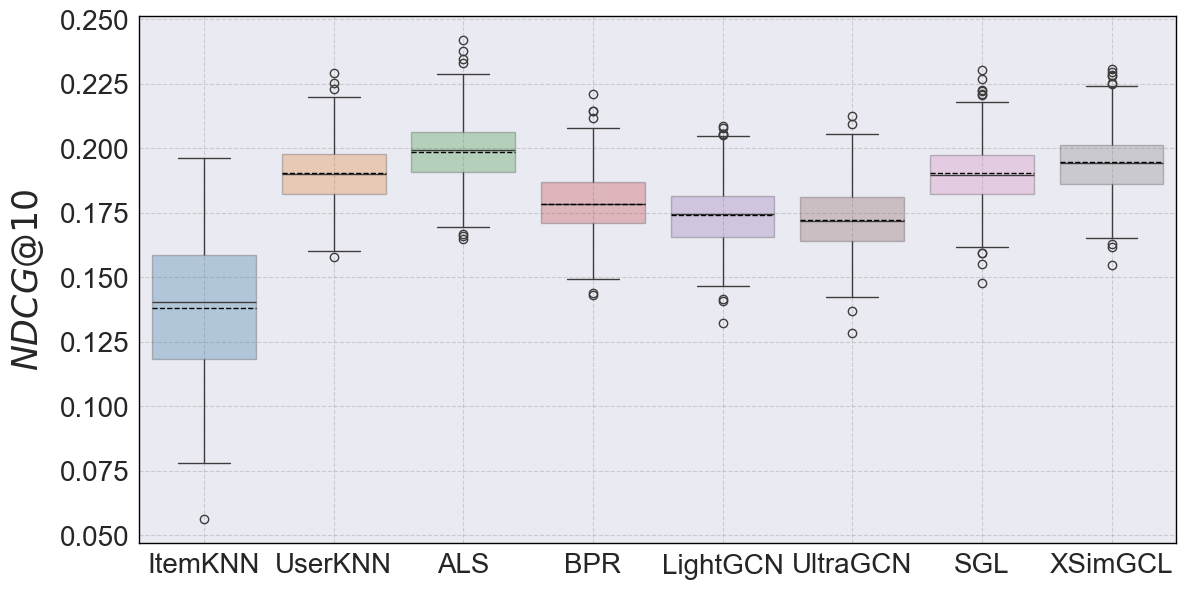

In [193]:
# Example usage: Plot MR@10 and NDCG@10
model_list = ['AsymItemKNN', 'AsymUserKNN', 'ALS',  'BPR', 'LightGCN', 'UltraGCN', 'SGL', 'XSimGCL']
model_name_list = ['ItemKNN', 'UserKNN', 'ALS', 'BPR', 'LightGCN', 'UltraGCN', 'SGL', 'XSimGCL']
plot_metrics_by_dataset_with_boxplot(final_eval_df, "ndcg@10", dataset_range=[1,176], models=model_list, model_names=model_name_list, save_fig = True, with_scatter=False)

In [53]:
def plot_user_characteristics_per_dataset(df, metrics, dataset_range=None, metric_labels=None, metric_colors=None, ylabel="", save_fig=False):
    # Validate metrics list
    valid_metrics = [
        'best_users_mean_popularity_mean', 'best_users_median_popularity_mean',
        'worst_users_mean_popularity_mean', 'worst_users_median_popularity_mean',
        'best_users_node_degree_mean', 'best_users_node_degree_median',
        'worst_users_node_degree_mean', 'worst_users_node_degree_median'
    ]
    for metric in metrics:
        if metric not in valid_metrics:
            raise ValueError(f"Invalid metric '{metric}'. Choose a valid metric.")

    # Filter dataframe based on dataset range if provided
    if dataset_range:
        integer1, integer2 = dataset_range
        df = df[(df['dataset'] >= integer1) & (df['dataset'] <= integer2)]

    # Melt the dataframe to long format for hue functionality
    df_long = df.melt(id_vars=['dataset'], value_vars=metrics, 
                      var_name='metric', value_name='value')

    # Initialize plot
    plt.figure(figsize=(12, 6))

    # Plot the metrics with hue as 'metric' and custom color mapping
    sns.lineplot(x='dataset', y='value', hue='metric', data=df_long,
                 palette=metric_colors, marker='o', markersize=4,
                 errorbar=lambda x: (x.min(), x.max()))

    # Customize plot
    plt.xlabel('Dataset #', fontsize=20)
    plt.ylabel(f"{ylabel}", fontsize=25, labelpad=10)

    # Create custom legend handles for consistent line styles and colors
    legend_handles = [
        Line2D([0], [0], color=metric_colors[metric], lw=2, label=metric_labels.get(metric, metric.replace('_', ' ').title()))
        for metric in metrics
    ]

    # Resize and position legend
    plt.legend(
        handles=legend_handles,
        fontsize=20,  # Font size for the legend labels (text)
        bbox_to_anchor=(0.5, -0.2),  # Adjusted position
        loc='upper center',  # Align legend at the top-left relative to bbox
        borderaxespad=0.5,  # Padding between legend and axes
        markerscale=1.5,  # Scale marker size in legend
        labelspacing=0.5,  # Space between legend entries
        handlelength=2.0,  # Length of legend line
        framealpha=0.4,
        ncol=4
    )

    # Customize axis spines
    ax = plt.gca()  # Get current axes
    for spine in ax.spines.values():
        spine.set_edgecolor('black')  # Set the color of the border
        spine.set_linewidth(1)  # Set the thickness of the border

    plt.yticks(fontsize=20)

    # Display grid
    plt.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.3, color='gray')

    if dataset_range and dataset_range[1] >= 176:
        xticks = list(range(10, 176, 20))
        plt.xticks(xticks, fontsize=20)  # Adjust step size (e.g., 10) for better label visibility
        
    plt.subplots_adjust(bottom=0.25)
        
    if save_fig: plt.savefig(f"../plots/best_worst_characteristics_datasets_{ylabel.replace(" ", "").lower()}.png", dpi=300, transparent=True)

    # Display the plot
    plt.show()


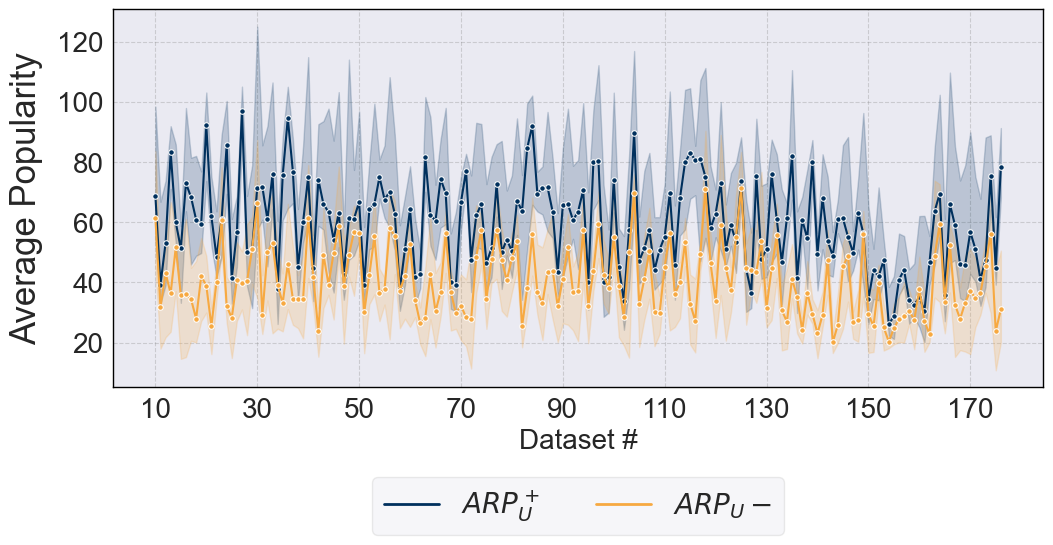

In [54]:
# Define a custom color palette for each metric
metric_colors = {
    'best_users_mean_popularity_mean': tu_dd_blue,
    'best_users_median_popularity_mean': tu_dd_blue,
    'worst_users_mean_popularity_mean': dd_concept_leh_orange,
    'worst_users_median_popularity_mean': dd_concept_leh_orange,
    'best_users_node_degree_mean': tu_dd_blue,
    'best_users_node_degree_median': tu_dd_blue,
    'worst_users_node_degree_mean': dd_concept_leh_orange,
    'worst_users_node_degree_median': dd_concept_leh_orange
}
# Define custom labels for metrics
metric_labels = {
    'best_users_mean_popularity_mean': '$ARP_U^+$',
    'best_users_median_popularity_mean': '$ARP_U+$ (Median)',
    'worst_users_mean_popularity_mean': '$ARP_U-$',
    'worst_users_median_popularity_mean': '$ARP_U-$ (Median)',
    'best_users_node_degree_mean': '$AvgDeg_U+$',
    'best_users_node_degree_median': '$AvgDeg_U+$ (Median)',
    'worst_users_node_degree_mean': '$AvgDeg_U+$',
    'worst_users_node_degree_median': ' $AvgDeg_U-$ (Median)',
    'average_clustering_coef_dot_best_users': '$AvgClustC_U+$',
    'average_clustering_coef_dot_worst_users': '$AvgClustC_U-$',
    'degree_assort_best_users': '$Assort_U+$',
    'degree_assort_worst_users': '$Assort_U-$',
}

# Call the function with custom labels
plot_user_characteristics_per_dataset(final_eval_df, metrics=['best_users_mean_popularity_mean', 'worst_users_mean_popularity_mean'],  dataset_range=(10, 180), metric_labels=metric_labels, metric_colors=metric_colors, ylabel="Average Popularity", save_fig=True)

In [57]:
def plot_regression(df, models, dataset_range=None, model_names=None, metric='best_users_mean_popularity_mean', target_metric='ndcg@10', transformation='log', metric_labels=None, save_fig=False):
    # Ensure the metric exists in the dataframe
    if metric not in df.columns:
        raise ValueError(f"Metric '{metric}' not found in dataframe columns.")
    if target_metric not in df.columns:
        raise ValueError(f"Target metric '{target_metric}' not found in dataframe columns.")
    
    # Set custom labels if provided, else use the column names
    metric_label = metric_labels.get(metric, metric.replace('_', ' ').title()) if metric_labels else metric.replace('_', ' ').title()

    # Filter the dataframe by dataset range if provided
    if dataset_range:
        lower_bound, upper_bound = dataset_range
        df = df[(df['dataset'] >= lower_bound) & (df['dataset'] <= upper_bound)]

    # Set model names if not provided
    if model_names is None:
        model_names = models

    # Ensure models are provided and filter the dataframe accordingly
    if models:
        df = df[df['Model'].isin(models)]  # Filter by the models in the 'models' list
        df['Model'] = pd.Categorical(df['Model'], categories=model_names, ordered=True)  # Set model categories

    # Prepare a plot for each model
    plt.figure(figsize=(12, 6))
    for model_name in model_names:
        model_df = df[df['Model'] == model_name]  # Filter for the current model
        
        # Extract metric values and target values for the current model
        model_metric_values = pd.to_numeric(model_df[metric].dropna())
        model_target_values = pd.to_numeric(model_df[target_metric].dropna())

        if len(model_metric_values) == 0 or len(model_target_values) == 0:
            continue  # Skip this model if no valid data points are found

        # Apply data transformation if needed
        if transformation == 'log':
            model_metric_values = np.log1p(model_metric_values)  # Log transform
        elif transformation == 'sqrt':
            model_metric_values = np.sqrt(model_metric_values)  # Sqrt transform
        
        # Combine transformed metrics and targets into a DataFrame
        model_combined_df = pd.DataFrame({metric: model_metric_values, target_metric: model_target_values}).dropna()

        # Plot regression using seaborn's regplot
        sns.regplot(
            x=model_combined_df[metric],
            y=model_combined_df[target_metric],
            scatter=True,
            label=f"{model_name} (Data)",
            scatter_kws={"s": 60, "alpha": 0.6},  # Customize scatter points
            line_kws={"label": f"{model_name} (Regression Line)"},  # Label for the regression line
        )
    
    ax = plt.gca()  # Get current axes
    for spine in ax.spines.values():
        spine.set_edgecolor('black')  # Set the color of the border
        spine.set_linewidth(1)  # Set the thickness of the border
    
    # Display grid
    plt.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.3, color='gray')

    # Display the plot
    plt.tight_layout()

    # Customize the plot
    plt.xlabel(f'{metric_label}', fontsize=25)
    plt.ylabel('NDCG@10', fontsize=25)
    plt.yticks(fontsize=20)
    plt.xticks(fontsize=20)

    # Save figure if requested
    if save_fig:
        plt.savefig(f"../plots/users_characteristics_against_metric_{metric}.png", dpi=300, transparent=True)

    # Show the plot
    plt.show()

C:\Users\s8347434\Documents\RecBole-GNN\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


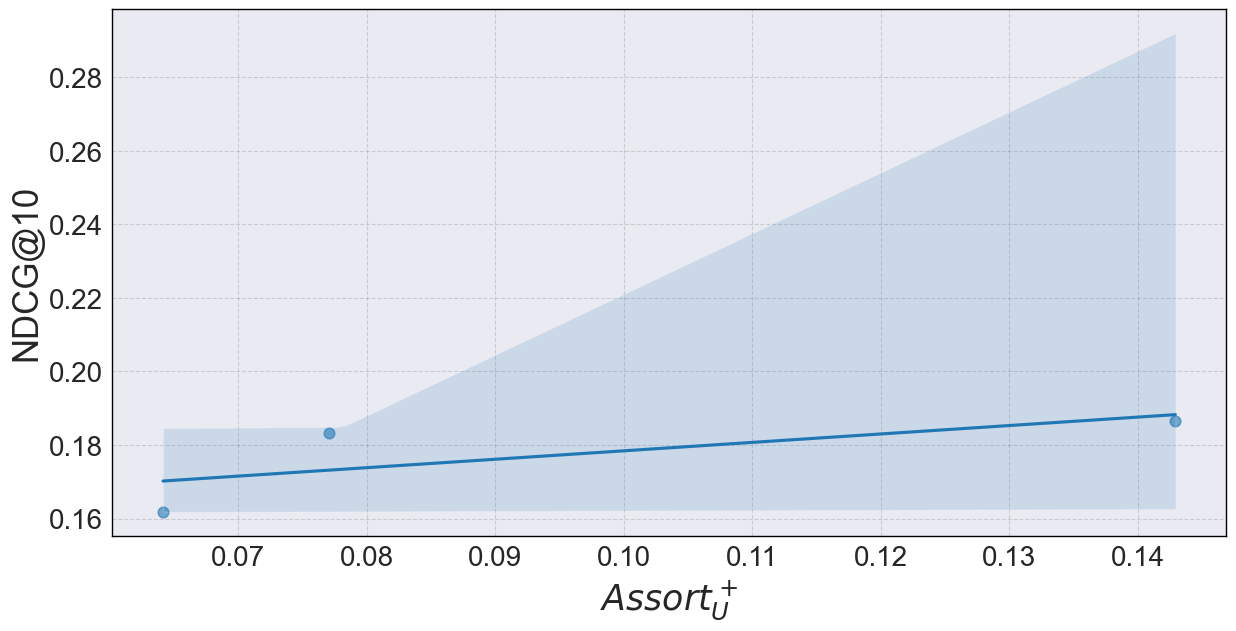

In [196]:
# Define custom labels for metrics and target metrics
metric_labels = {
    'best_users_mean_popularity_mean': '$ARP_{U^+]$',
    'best_users_median_popularity_mean': '$ARP_U^+$ (Median)',
    'worst_users_mean_popularity_mean': '$ARP_U^-$',
    'worst_users_median_popularity_mean': '$ARP_U^-$ (Median)',
    'best_users_node_degree_mean': '$AvgDeg_U^+$',
    'best_users_node_degree_median': '$AvgDeg_U^+$ (Median)',
    'worst_users_node_degree_mean': '$AvgDeg_U^+$',
    'worst_users_node_degree_median': ' $AvgDeg_U^-$ (Median)',
    'average_clustering_coef_dot_best_users': '$AvgClustC_U^+$',
    'average_clustering_coef_dot_worst_users': '$AvgClustC_U^-$',
    'degree_assort_best_users': '$Assort_U^+$',
    'degree_assort_worst_users': '$Assort_U^-$',
}

# Call the function with custom labels
plot_regression(final_eval_df, models=['LightGCN'], 
                dataset_range=[1,176], 
                metric='degree_assort_best_users', 
                target_metric='ndcg@10',
                metric_labels=metric_labels, 
                transformation='sqrt',
                save_fig=True)

In [33]:
def plot_correlation_matrix(df, models, dataset_range=None, model_names=None, metric_labels=None, metrics=['best_users_mean_popularity_mean'], transformation='log', save_fig=False, filename=None):
    # Filter the dataframe by the dataset range if provided
    if dataset_range:
        lower_bound, upper_bound = dataset_range
        df = df[(df['dataset'] >= lower_bound) & (df['dataset'] <= upper_bound)]

    # Set model names if not provided
    if model_names is None:
        model_names = models

    # Ensure models are provided and filter the dataframe accordingly
    if models:
        df = df[df['Model'].isin(models)]  # Filter by the models in the 'models' list
        df['Model'] = pd.Categorical(df['Model'], categories=model_names, ordered=True)  # Set model categories

    colors = [tu_dd_blue, bu_green1, ing_blue1]
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

    # Prepare a plot for each model
    plt.figure(figsize=(12, 6))
    
    labels = [metric_labels.get(metric, metric.replace('_', ' ').title()) for metric in metrics]
    
    for model_name in model_names:
        model_df = df[df['Model'] == model_name].reset_index()  # Filter for the current model

        # Extract metric values and target values for the current model
        model_metric_values = model_df[metrics].apply(pd.to_numeric)

        # Apply data transformation if needed
        if transformation == 'log':
            # Apply log transformation (ensure no zero or negative values)
            model_metric_values = model_metric_values.apply(np.log1p)
        elif transformation == 'sqrt':
            # Apply square root transformation (ensure no negative values)
            model_metric_values =  model_metric_values.apply(np.sqrt)
    
        # Compute the correlation matrix
        correlation_matrix = model_metric_values.corr()
    
        # Plot the heatmap
        plt.figure(figsize=(12, 8))
        #sns.heatmap(correlation_matrix, annot=True, cmap=cmap, center=0, fmt='.3f', linewidths=0.5)
        sns.heatmap(correlation_matrix, yticklabels=labels, annot=True, cmap=cmap, center=0, fmt='.3f', linewidths=0.5)
        
         # Get current x-tick positions and set the labels
        tick_positions = np.arange(len(correlation_matrix.columns)) + 0.4
        # Rotate y-tick labels
        plt.yticks(rotation=0, ha='right', va='center', fontsize=16) 
        plt.xticks(ticks=tick_positions, labels=labels, rotation=45, ha='left', va='bottom', fontsize=16)
        plt.tick_params(axis='both', labelsize=16, labelbottom = False, bottom=False, top = False, labeltop=True)

    # Customize the plot
    plt.tight_layout()
    
        # Save figure if requested
    if save_fig:
        plt.savefig(f"../plots/{filename}", dpi=300, transparent=True)

    
    # Show the plot
    plt.show()

<Figure size 1200x600 with 0 Axes>

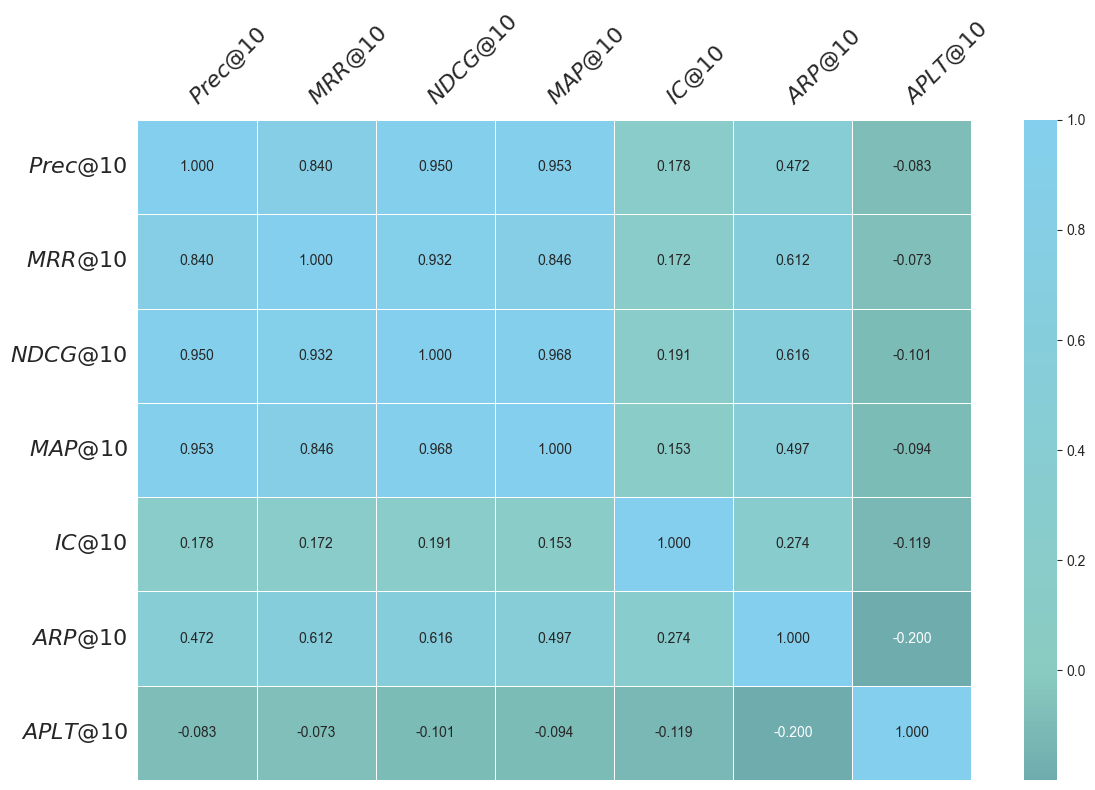

In [42]:
# Define custom labels for metrics and target metrics
metrics = ["precision@10", "mrr@10", "ndcg@10", "map@10", "itemcoverage@10", "averagepopularity@10","tailpercentage@10"]

metric_labels = {
    'best_users_mean_popularity_mean': '$ARP_U^+$',
    'best_users_median_popularity_mean': '$ARP_U+$ (Median)',
    'worst_users_mean_popularity_mean': '$ARP_U-$',
    'worst_users_median_popularity_mean': '$ARP_U-$ (Median)',
    'precision@10': "$Prec@10$",
    'mrr@10': "$MRR@10$",
    'ndcg@10': "$NDCG@10$",
    'map@10': "$MAP@10$",
    'itemcoverage@10': "$IC@10$",
    'averagepopularity@10': "$ARP@10$",
    'tailpercentage@10': "$APLT@10$",
}

plot_correlation_matrix(final_eval_df, models=['LightGCN'], dataset_range=[1,176], metric_labels=metric_labels, metrics=metrics, transformation=None, save_fig=True, filename="heatmap_evaluation_metrics.png")

<Figure size 1200x600 with 0 Axes>

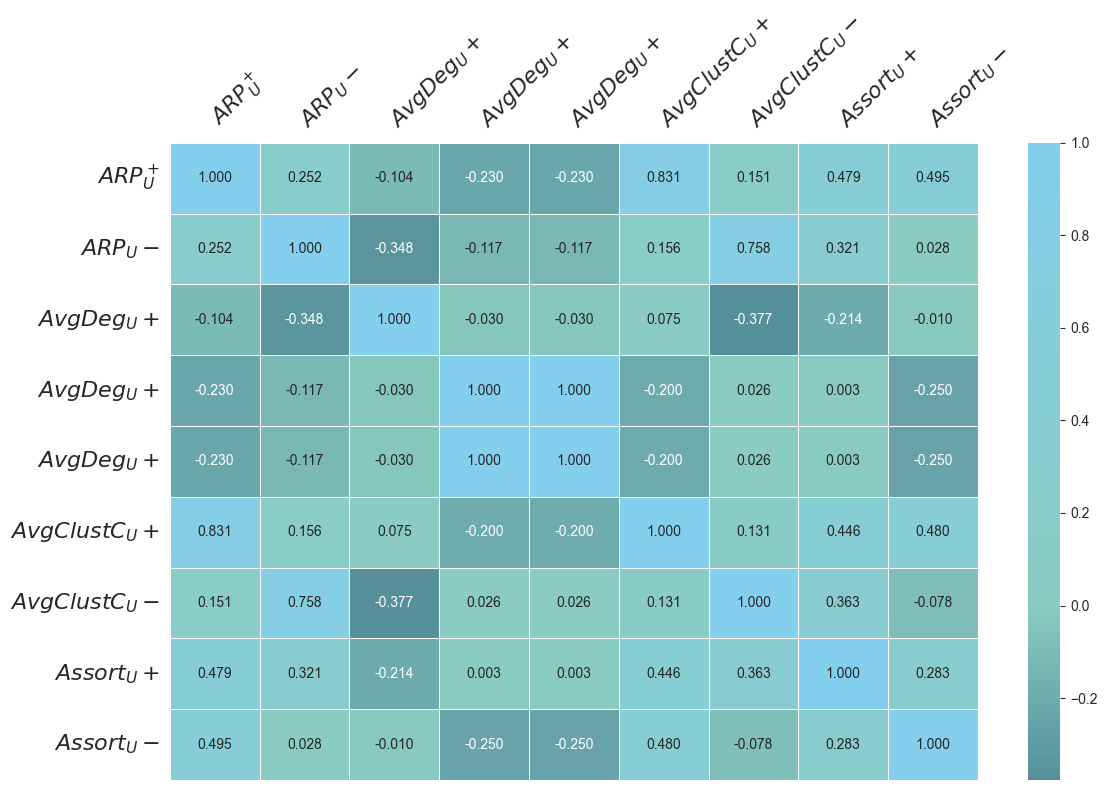

In [31]:
# Define custom labels for metrics and target metrics
metrics = ["best_users_mean_popularity_mean", "worst_users_mean_popularity_mean", "best_users_node_degree_mean", "worst_users_node_degree_mean","worst_users_node_degree_mean", "average_clustering_coef_dot_best_users", "average_clustering_coef_dot_worst_users", "degree_assort_best_users", "degree_assort_worst_users"]

metric_labels = {
    'best_users_mean_popularity_mean': '$ARP_U^+$',
    'best_users_median_popularity_mean': '$ARP_U+$ (Median)',
    'worst_users_mean_popularity_mean': '$ARP_U-$',
    'worst_users_median_popularity_mean': '$ARP_U-$ (Median)',
    'best_users_node_degree_mean': '$AvgDeg_U+$',
    'best_users_node_degree_median': '$AvgDeg_U+$ (Median)',
    'worst_users_node_degree_mean': '$AvgDeg_U+$',
    'worst_users_node_degree_median': ' $AvgDeg_U-$ (Median)',
    'average_clustering_coef_dot_best_users': '$AvgClustC_U+$',
    'average_clustering_coef_dot_worst_users': '$AvgClustC_U-$',
    'degree_assort_best_users': '$Assort_U+$',
    'degree_assort_worst_users': '$Assort_U-$',
}

plot_correlation_matrix(final_eval_df, models=['LightGCN'], dataset_range=[1,176], metric_labels=metric_labels, metrics=metrics, transformation='log', save_fig=True, filename="heatmap_worst_best_characteristics.png")

<Figure size 1200x600 with 0 Axes>

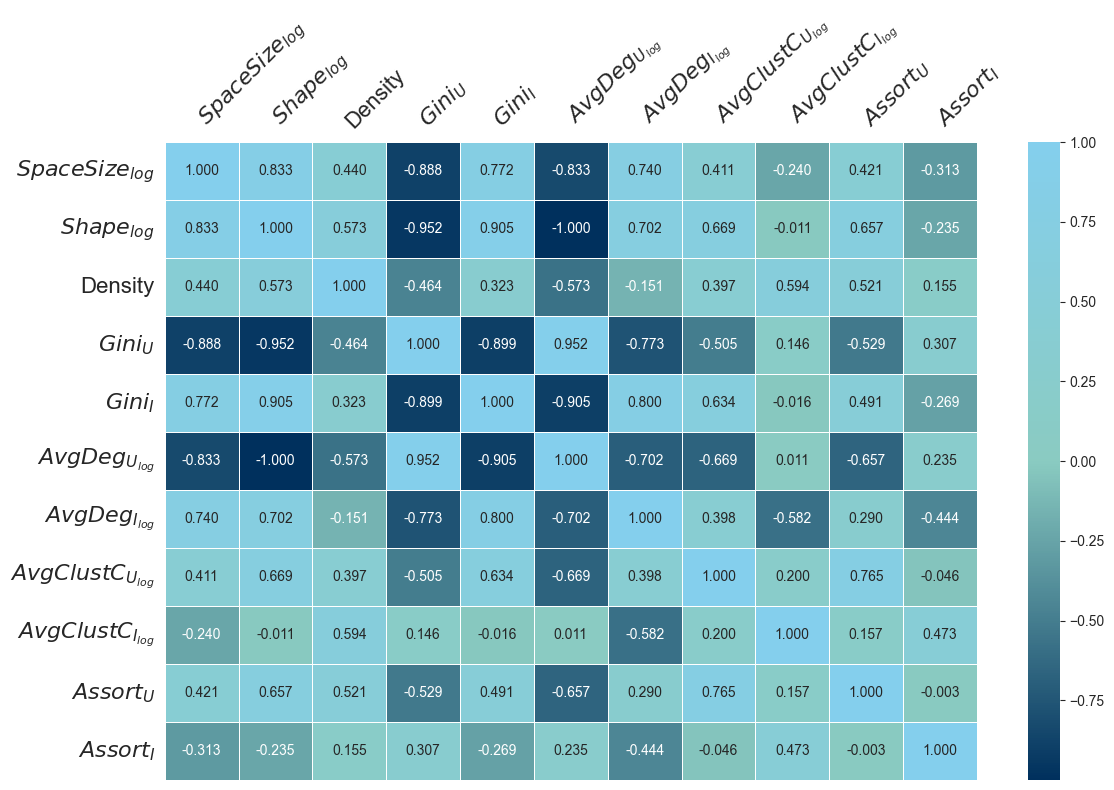

In [41]:
# Define custom labels for metrics and target metrics
metrics = ["space_size_log", "shape_log", "density", "gini_user", "gini_item", "average_degree_user_log", "average_degree_item_log", "average_clustering_coef_dot_user_log", "average_clustering_coef_dot_item_log", "degree_assort_user", "degree_assort_item"]

metric_labels = {'space_size_log' : '$SpaceSize_{log}$',
                   'shape_log' : '$Shape_{log}$',
                    'sparsity_log' : '$Sparsity_{log}$',
                   'gini_user' : '$Gini_U$',
                   'gini_item' : '$Gini_I$',
                   'average_degree_user_log' : '$AvgDeg_{U_{log}}$',
                   'average_degree_item_log' : '$AvgDeg_{I_{log}}$',
                   'average_clustering_coef_dot_user_log' : '$AvgClustC_{U_{log}}$',
                   'average_clustering_coef_dot_item_log' : '$AvgClustC_{I_{log}}$',
                   'degree_assort_user' : '$Assort_U$',
                   'degree_assort_item' : '$Assort_I$'}

plot_correlation_matrix(final_eval_df, models=['LightGCN'], dataset_range=[1,176], metric_labels=metric_labels, metrics=metrics, transformation=None, save_fig=True, filename="heatmap_dataset_characterisics.png")

#### Statistical Significance

In [56]:
import matplotlib.pyplot as plt
from scipy.stats import probplot

def plot_qq_residuals(residuals_normalized, save_fig=False, filename="", plot_show=False):
    """
    Plot a QQ plot of residuals against a normal distribution.
    
    Parameters:
        residuals_normalized (array-like): The residuals from a regression model.
        line_color (str): Color for the 45-degree line (default 'red').
        scatter_color (str): Color for the scatter points (default 'blue').
    
    Returns:
        None
    """
    fig, ax = plt.subplots()

    # Create QQ plot
    QQ = probplot(residuals_normalized, dist="norm", plot=ax)

    # Customize line properties for the QQ plot (set color and line width)
    line = ax.get_lines()[1]  # Get the 45-degree reference line
    line.set_linewidth(2)  # Increase the line thickness
    line.set_color(dd_concept_med_red)  # Set the color of the line
    
    scatter = ax.get_lines()[0]  # Get the 45-degree reference line
    scatter.set_linewidth(2)  # Increase the line thickness
    scatter.set_color(tu_dd_blue)  # Set the color of the line
    scatter.set_markerfacecolor(tu_dd_blue)
    scatter.set_markersize(12.0)
    scatter.set_alpha(0.5)

    # Customize axis spines
    ax = plt.gca()  # Get current axes
    for spine in ax.spines.values():
        spine.set_edgecolor('black')  # Set the color of the border
        spine.set_linewidth(1)  # Set the thickness of the border

    # Customize the plot
    plt.xlabel("Theoretical Quantiles", fontsize=20, labelpad=10)
    plt.ylabel("Ordered Residuals", fontsize=20, labelpad=10)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.title("")

    # Add a label to the line (for the legend)
    plt.plot([], [], color=dd_concept_med_red, lw=1.5, alpha=0.8, label='Cummulative Normal Probability')
    plt.scatter([], [], color=tu_dd_blue, lw=1.5, alpha=0.8, label='Residuals')

    # Resize and position the legend
    plt.legend(
        fontsize=16,  # Font size for the legend labels (text)
        bbox_to_anchor=(0.5, -0.35),  # Adjusted position below the plot
        loc='upper center',  # Align legend at the top-left relative to bbox
        borderaxespad=0.5,  # Padding between legend and axes
        markerscale=1.5,  # Scale marker size in legend
        labelspacing=0.5,  # Space between legend entries
        handlelength=2.0,  # Length of legend line
        framealpha=0.4,  # Transparency of the legend box
        ncol=2  # Number of columns in the legend
    )

    # Display grid
    plt.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.3, color='gray')

    # Tight layout for optimal spacing
    plt.tight_layout()

    # Save the figure if requested
    if save_fig:
        plt.savefig(f"../plots/{filename}", dpi=300, transparent=True, bbox_inches='tight')

    # Show the plot
    if plot_show: 
        plt.show()
    else:
        plt.close()


In [57]:
def residuals_vs_fitted_values(externally_studentized_residuals, metric, y_pred, filename="", plot_show=False):
    # Plot externally studentized residuals
    plt.figure(figsize=(8, 5))
    #plt.scatter(y_pred, externally_studentized_residuals, alpha=0.7, label="Externally Studentized Residuals", color=tu_dd_blue)
    #plt.axhline(0, color=dd_concept_med_red, linestyle="--", linewidth=1.5, label="Zero Line")

    sns.residplot(
        x=y_pred,
        y=externally_studentized_residuals,
        lowess=True,
        scatter_kws={'alpha': 0.5, 'color': tu_dd_blue},
        line_kws={'color': dd_concept_med_red, 'lw': 1.5, 'alpha': 0.8})
    
    # Add a custom legend for the scatter and line
    plt.scatter([], [], color=tu_dd_blue, alpha=0.5, label="Residuals")  # Dummy point for legend
    plt.plot([], [], color=dd_concept_med_red, label="Lowess Line")  # Dummy line for legend
    
    plt.xlabel("X")
    plt.ylabel("Residuals")
    # Resize and position the legend
    plt.legend(
        fontsize=16,  # Font size for the legend labels (text)
        bbox_to_anchor=(0.5, -0.25),  # Adjusted position below the plot
        loc='upper center',  # Align legend at the top-left relative to bbox
        borderaxespad=0.5,  # Padding between legend and axes
        markerscale=1.5,  # Scale marker size in legend
        labelspacing=0.5,  # Space between legend entries
        handlelength=2.0,  # Length of legend line
        framealpha=0.4,  # Transparency of the legend box
        ncol=2  # Number of columns in the legend
    )
    
    # Customize plot
    plt.ylabel("Residuals", fontsize=20, labelpad=10)
    plt.xlabel(f'Fitted values {metric}', fontsize=20, labelpad=10)
    
    # Customize ticks
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    # Customize axis spins
    ax = plt.gca()  # Get current axes
    for spine in ax.spines.values():
        spine.set_edgecolor('black')  # Set the color of the border
        spine.set_linewidth(1)  # Set the thickness of the border
    
    plt.savefig(f"../plots/{filename}", dpi=300, transparent=True, bbox_inches='tight')
    
    # Show the plot
    if plot_show: 
        plt.show()
    else:
        plt.close()

In [83]:
def influence_plot(models, metrics, df_results, plot_show=False):

    # Define the p-value categorization function
    def categorize_p_value(p):
        if p <= 0.001:
            return tu_dd_blue  # Highly statistically significant
        elif p <= 0.01:
            return bu_green3  # Statistically significant
        elif p <= 0.05:
            return bu_green2  # Marginally significant
        else:
            return bu_green1 # Not statistically significant
    
    # Calculate dynamic figure width
    num_metrics = len(characteristics)
    min_width = 8  # Minimum width of the figure
    height = 8
    
    for model in models:
        # Create the barplot
        fig, ax = plt.subplots(1, len(metrics), figsize=(20, height))
        model_entry = df_results[df_results['model'] == model]
        
        for i, metric in enumerate(metrics.items()):
            axis = ax[i]
                    
            # Extract the first row for the model you want to plot
            row = model_entry[model_entry['metric'] == metric[0]].iloc[0]
                    
            # Create lists of metrics, impacts, and p_values
            impacts = [row[f"{characteristic}"] for characteristic in characteristics.keys()]
            p_values = [row[f"p_{characteristic}"] for characteristic in characteristics.keys()]
            
            # Assign colors based on p-value categorization
            colors = [categorize_p_value(p) for p in p_values]
            
            bars = axis.barh(characteristics.keys(), impacts, color=colors)
        
            # Customize plot
            axis.set_xlabel(f"Impact on {metric[1]}", fontsize=25, labelpad=10)
            axis.set_ylabel("")
            axis.set_title(f"adj. $R^2={row['adjusted_score']:.3f}$", fontsize=20)
            
            for spine in axis.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(0.8)
                spine.set_color('black')
        
            # Display grid
            axis.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.3, color='gray') # Example labels    
        
            if i==0:
                # Customize y-tick labels
                custom_yticks = [f"{label_name}" for label_name in characteristics.values()] 
                # Set the y-ticks for the specific subplot
                axis.set_yticks(range(len(characteristics)))
                axis.set_yticklabels(custom_yticks, fontsize=20) 
            if i>0:
                axis.set_yticklabels("", fontsize=15) 
        
                
            # Customize ticks
            axis.tick_params(axis='x', labelsize=20)
            
            axis.axvline(0)
        
        
        # Add a legend for the p-value ranges
        legend_handles = [
            mpatches.Patch(color=tu_dd_blue, label="p ≤ 0.001"),
            mpatches.Patch(color=bu_green3, label="p ≤ 0.01"),
            mpatches.Patch(color=bu_green2, label="p ≤ 0.05"),
            mpatches.Patch(color=bu_green1, label="Not significant"),
            
        ]
        fig.legend(
            handles=legend_handles,
            fontsize=16,
            bbox_to_anchor=(0.5, -0.1),
            loc="lower center",
            ncol=4,
            framealpha=0.4,
        )
        
        # Save the plot
        plt.savefig(f"../plots/evaluation_impact_{model}.png", dpi=300, transparent=True, bbox_inches='tight')
        
        if plot_show: 
            plt.show()
        else:
            plt.close()

In [85]:
def significance_test(df, characteristics, models, metrics, transformation = 'log', transform_target=False, plot_show=False):
    # Center the data (subtract the mean of each feature)
    data = df[df['Model'].isin(models)].reset_index(drop=True).copy()
    sanitized_columns = {col: col.split('@')[0] for col in df.columns}
    data = data.rename(columns=sanitized_columns)

    metric_keys = list(metrics.keys())
    
    data[list(characteristics.keys())] = data[list(characteristics.keys())].apply(pd.to_numeric)
    data[metric_keys] = data[metric_keys].apply(pd.to_numeric)

    if transformation == 'log':
        if transform_target:
            data[metric_keys] = data[metric_keys].apply(np.log10)
        log_characteristics = [characteristic for characteristic in characteristics.keys() if not characteristic.startswith('degree')]
        data[log_characteristics] = data[log_characteristics].apply(np.log10)
    elif transformation == 'square':
        if transform_target:
            data[metric_keys] = data[metric_keys].apply(np.sqrt)
        log_characteristics = [characteristic for characteristic in characteristics.keys() if not characteristic.startswith('degree')]
        data[log_characteristics] = data[log_characteristics].apply(np.sqrt)

    data[list(characteristics.keys())] = data[list(characteristics.keys())].apply(lambda x: x - x.mean())

    # Iterate over the metrics to create the new columns
    df_new = pd.DataFrame()
    
    for model in models:
        for metric in metric_keys:
            df_new[f"{model}_{metric}"] = data[data['Model']==model][metric].reset_index(drop=True)
        for characteristic in characteristics:
            df_new[characteristic] = data[data['Model']==model][characteristic].reset_index(drop=True)

    # Randomly split data into training and test sets (90% training, 10% test)
    #msk = np.random.rand(len(df_new)) < 0.9
    #test = df_new[~msk]
    train = df_new

    # List to store the regression results
    models_results = []

    # Iterate over each metric
    for metric_key, metric_value in metrics.items():
        # Iterate over each model
        for idx, model in enumerate(models):
            X = train[list(characteristics.keys())]
            y = train[model + '_' + metric_key]  # Use the newly created column
            
            # Define the formula for OLS regression
            formula_str_ml = y.name + ' ~ ' + '+'.join(list(characteristics.keys()))
            
            # Perform OLS regression using statsmodels
            #X = sm.add_constant(X)  # Adds a column of ones for the intercept term
            model_ml = sm.ols(formula=formula_str_ml, data=train[list(characteristics.keys())+[model + '_' + metric_key]])
            fitted_ml = model_ml.fit(cov_type='HC1')  # Robust standard errors (HC1)

            print(fitted_ml.summary())
            print("Parameters: ", fitted_ml.params)
            print("R2: ", fitted_ml.rsquared)
          
            # Plot Residuals vs. Distribution
            influence = fitted_ml.get_influence()
            externally_studentized_residuals = influence.resid_studentized_external
            #plot_qq_residuals(externally_studentized_residuals, save_fig=True, filename=f"external_studentized_residuals_vs_probability_plot_{model}_{metric_key}", plot_show=plot_show)
            
            # Plot Residuals vs. fitted values
            y_pred = fitted_ml.fittedvalues 
            #residuals_vs_fitted_values(externally_studentized_residuals, metric_value, y_pred, filename=f"external_studentized_residuals_vs_fitted_values_{model}_{metric_key}.png", plot_show=plot_show)
            
            # Append the results to models_results
            models_results.append({
                'model': model,
                'metric': metric_key,
                'score': fitted_ml.rsquared,
                'adjusted_score': fitted_ml.rsquared_adj,
                **fitted_ml.params.to_dict(),  # Coefficients
                **fitted_ml.pvalues.rename(lambda x: 'p_' + x).to_dict()  # p-values
            })
            
        
    # Convert the results to a DataFrame
    df_results = pd.DataFrame.from_dict(models_results)
    
    print(df_results)

    df_results.to_csv(f"RO/significance_test_RO.csv", sep='\t', index=None)
    
    return fitted_ml, X, y, df_results
    
    # Regression plots: https://www.statsmodels.org/dev/examples/notebooks/generated/regression_plots.html


In [94]:
# same characteristics as in https://dl.acm.org/doi/pdf/10.1145/3640457.3688070
characteristics = {'best_users_mean_popularity_mean': '$ARP_U^+$',
                   'gini_user': '$Gini_U$',
                   'gini_item': '$Gini_I$',
                    'average_degree': '$AvgDeg$',
                   'degree_assort_user': '$Assort_U$',
                   'degree_assort_item': '$Assort_I$'}

characteristics = {#'space_size_log' : '$SpaceSize_{log}$',
                   'shape' : '$Shape$',
                    #'user_num' : '$|U|$',
                   #'item_num' : '$||I$',
                    #'density' : '$Sparsity_{log}$',
                   #'gini_user' : '$Gini_U$',
                   #'gini_item' : '$Gini_I$',
                   'average_degree_user_log' : '$AvgDeg_{U_{log}}$',
                   'average_degree_item_log' : '$AvgDeg_{I_{log}}$',
                   'average_clustering_coef_dot_user_log' : '$AvgClustC_{U_{log}}$',
                   'average_clustering_coef_dot_item_log' : '$AvgClustC_{I_{log}}$',
                   'degree_assort_user' : '$Assort_U$',
                   'degree_assort_item' : '$Assort_I$'
                    }

# SpaceSize & Shape or Sparsity strong multicollinearity!

models = ['ALS']
metrics = {'ndcg' : '$NDCG@10$'}

models = ['ALS','AsymItemKNN', 'AsymUserKNN', 'BPR', 'LightGCN', 'UltraGCN', 'SGL', 'XSimGCL']
metrics = {'ndcg' : '$NDCG@10$', 'itemcoverage' : '$IC@10$', 'averagepopularity' : '$ARP@10$', 'tailpercentage' : '$APLT@10$'}

fitted_ml, X, y, df_results = significance_test(final_eval_df, characteristics, models, metrics, transformation=None, transform_target=False, plot_show=False)

# Plot the influence
#influence_plot(models, metrics, df_results, plot_show=False)

                            OLS Regression Results                            
Dep. Variable:               ALS_ndcg   R-squared:                       0.581
Model:                            OLS   Adj. R-squared:                  0.563
Method:                 Least Squares   F-statistic:                     32.76
Date:                Tue, 28 Jan 2025   Prob (F-statistic):           2.09e-28
Time:                        16:42:55   Log-Likelihood:                 589.79
No. Observations:                 176   AIC:                            -1164.
Df Residuals:                     168   BIC:                            -1138.
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


NameError: name 'ax' is not defined

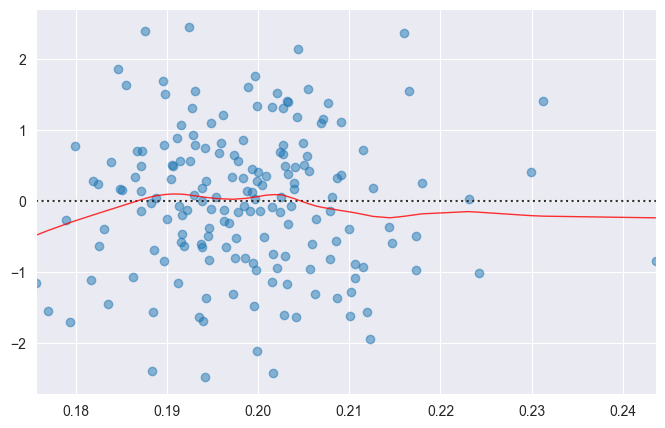

In [33]:
# Plot Residuals vs. Distribution
influence = fitted_ml.get_influence()
externally_studentized_residuals = influence.resid_studentized_external
y_pred = fitted_ml.fittedvalues 

plt.figure(figsize=(8, 5))


sns.residplot(
    x=y_pred,
    y=externally_studentized_residuals,
    lowess=True,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})

# annotations
residual_abs = np.abs(externally_studentized_residuals)
abs_resid = np.flip(np.argsort(residual_abs), 0)
abs_resid_top_3 = abs_resid[:3]
for i in abs_resid_top_3:
    ax.annotate(
        i,
        xy=(self.y_predict[i], self.residual[i]),
        color='C3')

plt.set_title('Residuals vs Fitted', fontweight="bold")
plt.set_xlabel('Fitted values')
plt.set_ylabel('Residuals')
plot.show()

In [ ]:
# Get the intercept and slope from the fitted model
metric = 'space_size_log'
intercept = fitted_ml.params['Intercept']  # Intercept
slope = fitted_ml.params[metric]  # Slope

# Use the intercept and slope to create the predicted values
y_pred = intercept + slope * X[metric]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot of actual data points (original sample)
ax.plot(X[metric], y, "o", label="$log(X_C-\\bar{X}_C)$", markersize=7)

# Plot the manually calculated fitted values (regression line)
ax.plot(X[metric], y_pred, "r--.", label="$\\hat{y}$", linewidth=2)

ax.set_ylabel('$NDCG@10$')  # Label for Y-axis

plt.legend(
    fontsize=18,
    bbox_to_anchor=(0.5, -0.2),
    loc="upper center",
    ncol=4,
    framealpha=0.4,
)

    
ax = plt.gca()  # Get current axes
for spine in ax.spines.values():
    spine.set_edgecolor('black')  # Set the color of the border
    spine.set_linewidth(1)  # Set the thickness of the border

# Adjust layout and save
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
#plt.xlabel("$log(X_C-\\bar{X_C})$",fontsize=20)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)

plt.subplots_adjust(bottom=0.3)

# Save the plot
plt.savefig(f"../plots/fitted_model_{metric}.png", dpi=300, transparent=True)

plt.show()
